# probability

## Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\acer\Downloads\StudentsPerformance.xls")
print(df)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

## 1) Basic Probability

### Use probability when you want to know how likely an event is to happen.

Examples:
Probability of getting Head in a coin toss.
Probability of selecting a female student.
Probability of rolling a 6.

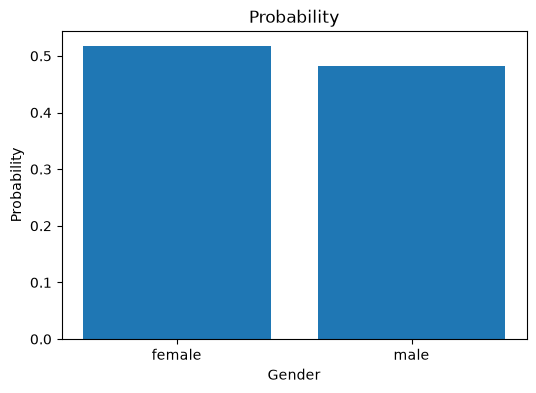

In [19]:
prob = df["gender"].value_counts(normalize=True)

plt.figure(figsize=(6,4))
plt.bar(prob.index, prob.values)

plt.title("Probability")
plt.xlabel("Gender")
plt.ylabel("Probability")

plt.show()

#### Explanation: This chart shows the probability of selecting a male or female student from the dataset.If Female = 0.52.It means,There is a 52% chance of selecting a female student randomly.

### 1.1) Classical probability

### Use it when all outcomes are equally likely.

Examples:
 * Rolling a fair die
 * Tossing a fair coin
 * Drawing one card from a shuffled deck
   
Formula
P(A)=
Total Number of Outcomes
Number of Favorable Outcomes
	
Example:

Probability of rolling a 4

P(4)= 1/6


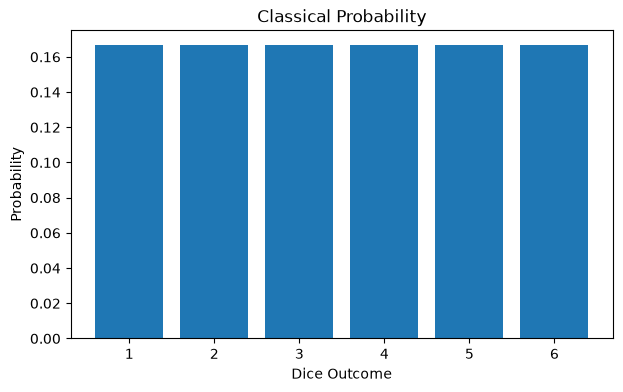

In [6]:
outcomes = ['1','2','3','4','5','6']       
prob = [1/6]*6

plt.figure(figsize=(7,4))
plt.bar(outcomes, prob)

plt.title("Classical Probability")
plt.xlabel("Dice Outcome")
plt.ylabel("Probability")

plt.show()

#### Explanation: Every bar has the same height because each outcome has the same probability.

### 1.2) Empirical Probability

### Use it when probability is calculated from observed data or experiments.

 Formula
P(A)=Total Number of Observations/Number of Times Event Occurred
	
Example:
A coin is tossed 100 times.

Results:
Heads = 58
Tails = 42

Probability of Heads

P(H)= 58/100 =0.58 

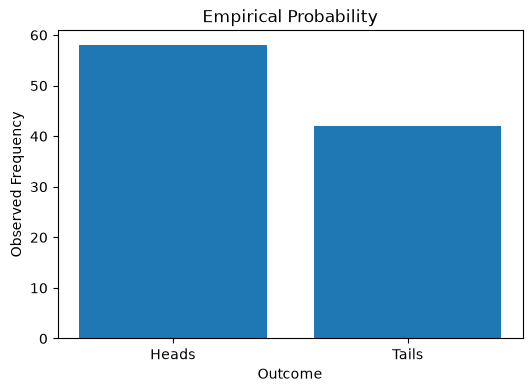

In [9]:
result = ["Heads","Tails"]
count = [58,42]

plt.figure(figsize=(6,4))
plt.bar(result, count)

plt.title("Empirical Probability")
plt.xlabel("Outcome")
plt.ylabel("Observed Frequency")

plt.show()

#### Explanation: Unlike classical probability, the bars are not equal because they come from actual observations.

### 1.3) Subjective Probability

### Use it when probability is based on personal judgment, experience, or expert opinion, rather than experiments or equally likely outcomes.

Examples:
Probability that it will rain tomorrow.
Probability a startup will succeed.
Probability a cricket team will win a match.

These probabilities are estimates and can differ between people.

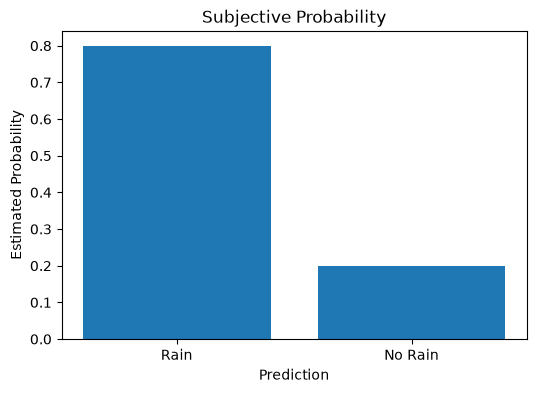

In [12]:
events = ["Rain","No Rain"]
prob = [0.8,0.2]

plt.figure(figsize=(6,4))
plt.bar(events, prob)

plt.title("Subjective Probability")
plt.xlabel("Prediction")
plt.ylabel("Estimated Probability")

plt.show()

#### Explanation: This chart represents a person's belief (for example, an 80% chance of rain). It is not derived from equally likely outcomes or repeated experiments.

## 2) Conditional Probability

### Use it when the probability depends on another event.

Formula 
P(A∣B)=P(A∩B)/P(B)
	

P(A∣B)=P(A∩B)/p(B)
P(A|B)= 0.30/0.65 = 0.46

P(B) = 0.65
P(A∩B) = 0.30 

Examples:
Probability of having standard lunch given the student is female.
Probability of passing given the student attended coaching.

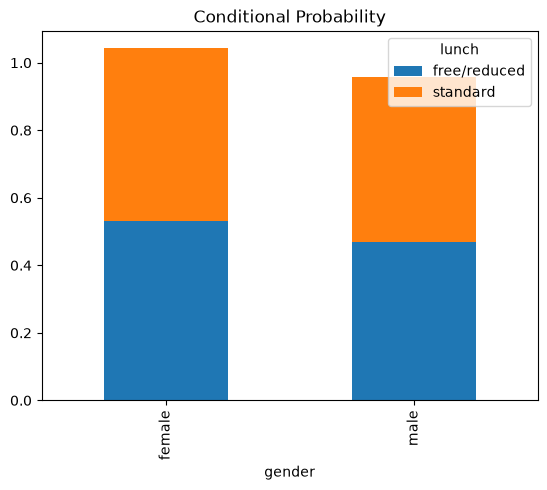

In [18]:
table = pd.crosstab(
    df["gender"],
    df["lunch"],
    normalize="columns"
)

table.plot(kind="bar", stacked=True)

plt.title("Conditional Probability")

plt.show()

#### Explanation: This chart shows,After knowing the lunch type, how the probabilities differ between male and female students.Conditional probability always answers questions that start with "given that..."

## 3) Bayes' Theorem

### Use Bayes' theorem when new information changes the probability.

Formula
P(A∣B)=P(B∣A)P(A)/P(B)

Examples:
Student scored above 80.

Find the probability that they completed the preparation course.

Disease testing.
Spam email detection.

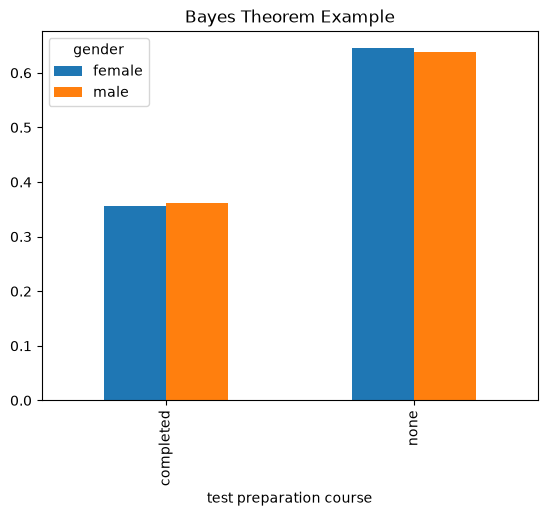

In [32]:
bayes = pd.crosstab(
    df["test preparation course"],
    df["gender"],
    normalize="columns"
)

bayes.plot(kind="bar")

plt.title("Bayes Theorem Example")
plt.show()

#### Explanation:This chart shows,After observing new evidence (test preparation), how the probability changes.Bayes' theorem updates an old probability using new information.

## 4) Inferential Statistics

### When collecting data from the entire population is impossible.

Examples:
Survey 500 people instead of 5 million.
Estimate election results.
Estimate average salary.

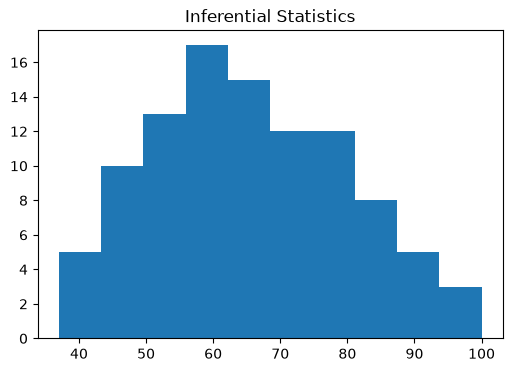

In [31]:
sample = df["math score"].sample(100)

plt.figure(figsize=(6,4))
plt.hist(sample)

plt.title("Inferential Statistics")

plt.show()

#### Explanation: Instead of analyzing all students,we analyze only a sample.Then,we estimate the average score of the whole population.

## 5) Probability Distribution

### A probability distribution shows how the probabilities of different values are distributed. In a dataset, we visualize it to understand which values occur more often and how the data is spread.

For example:

Do most students score between 50 and 70?
Are very high scores rare?
Is the distribution symmetric or skewed?

The best plot for a continuous variable is a histogram.

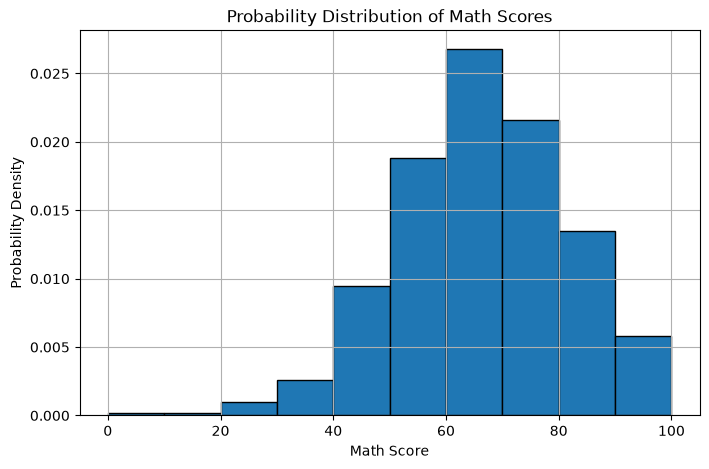

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    df["math score"],
    bins=10,
    density=True,      # Convert counts to probability density
    edgecolor="black"
)

plt.title("Probability Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Probability Density")
plt.grid(True)

plt.show()

#### Explanation: X-axis: Math scores.Y-axis: Probability density (how likely values are in each range).Taller bars indicate score ranges that occur more frequently.

## 5.1) Bernoulli Distribution

### Use a Bernoulli distribution when there is only one trial with two possible outcomes.

Possible outcomes:

Success (1)
Failure (0)
    
Examples:
Pass / Fail
Yes / No
Head / Tail
Purchased / Not Purchased

Formula
P(X=x)={p,x=1
        1-P,x=0

Example:

Probability of success = 0.7
Probability of failure = 0.3

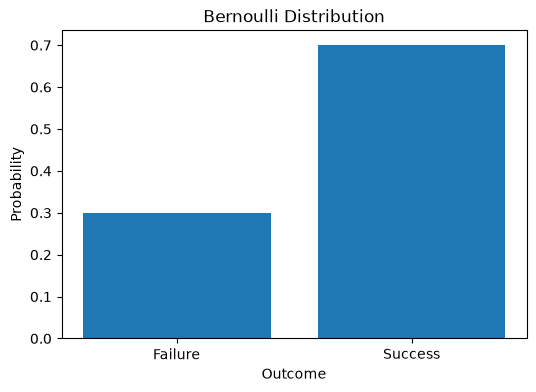

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# Probability of success
p = 0.7

x = [0, 1]
y = bernoulli.pmf(x, p)

plt.figure(figsize=(6,4))
plt.bar(x, y)

plt.title("Bernoulli Distribution")
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.xticks([0,1],["Failure","Success"])

plt.show()

#### Interpretation: One trial only,Probability of Success = 0.7,Probability of Failure = 0.3.

## 5.2) Binomial Distribution

### Use a Binomial distribution when there are multiple independent Bernoulli trials.

Examples:
Toss a coin 10 times.
Inspect 20 products for defects.
Count how many students pass out of 50.

Formula
P(X=x)=(n) P^x(1−p)^n-x
       (x)

Where:

n = Number of trials
x = Number of successes
p = Probability of success

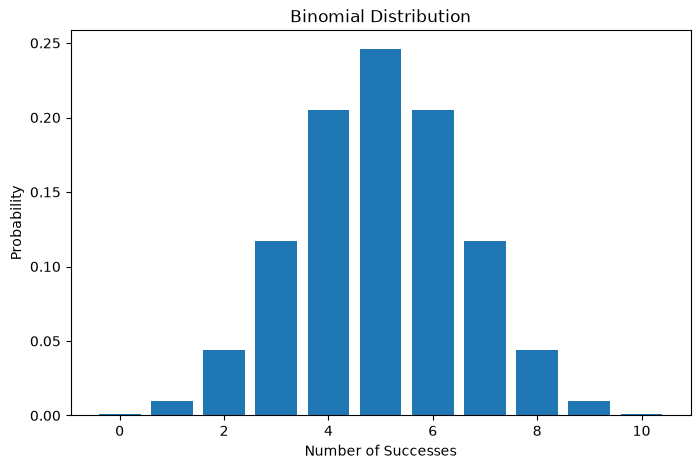

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 10
p = 0.5

x = np.arange(0, n+1)
y = binom.pmf(x, n, p)

plt.figure(figsize=(8,5))
plt.bar(x, y)

plt.title("Binomial Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")

plt.show()

#### Interpretation: 10 coin tosses.Shows the probability of getting 0, 1, 2, ..., 10 heads.The highest probability is around 5 heads.

## 5.3) Poisson Distribution

### Use a Poisson distribution to model the number of times an event occurs in a fixed interval of time or space.

Examples:
Customers arriving at a store per hour.
Phone calls received per minute.
Website visits per minute.
Accidents per day.

Formula
P(X=x)= e^−λ λ^x/x!

Where:

λ = Average number of events
x = Number of events observed

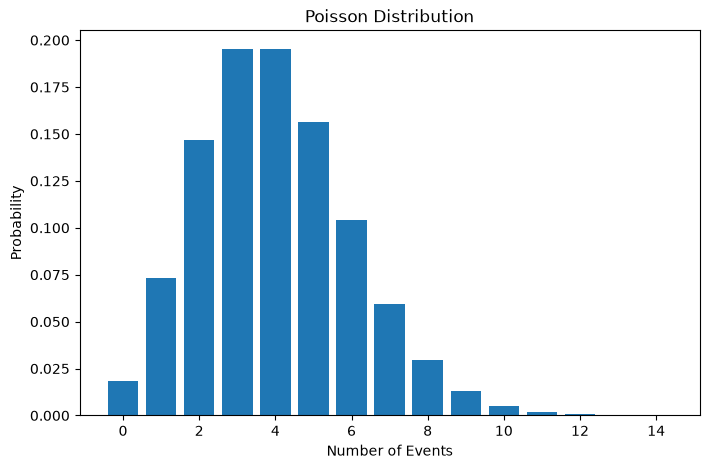

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

lam = 4

x = np.arange(0,15)
y = poisson.pmf(x, lam)

plt.figure(figsize=(8,5))
plt.bar(x, y)

plt.title("Poisson Distribution")
plt.xlabel("Number of Events")
plt.ylabel("Probability")

plt.show()

#### Interpretation: Average = 4 customers per hour.Shows the probability of observing 0, 1, 2, ... customers in an hour.

## 6) Sampling Techniques ---> 6 Types

### 6.1) Simple Random Sampling

### When every record should have an equal chance of selection.

Examples:
Select 100 customers randomly.
Randomly choose 50 students.

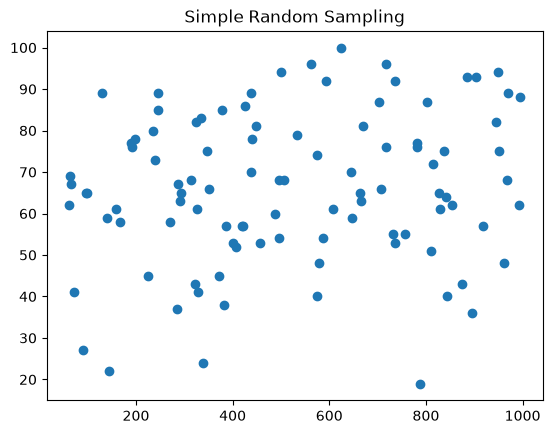

In [27]:
sample = df.sample(100)

plt.scatter(
    sample.index,
    sample["math score"]
)

plt.title("Simple Random Sampling")

plt.show()

#### Explanation: Every student has an equal probability of being selected.This reduces selection bias.

## 6.2) Systematic Sampling

### When data is already ordered.

Examples:
Every 10th customer.
Every 5th product.

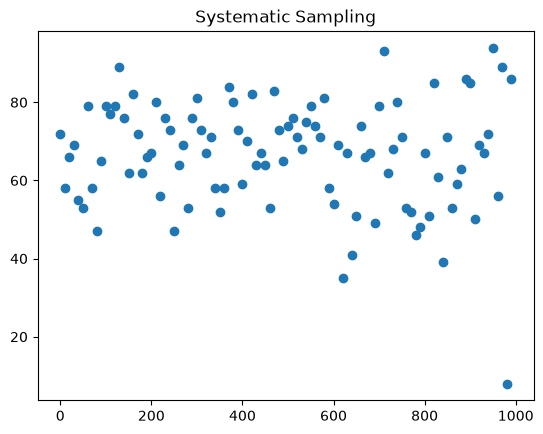

In [28]:
sample = df.iloc[::10]

plt.scatter(
    sample.index,
    sample["math score"]
)

plt.title("Systematic Sampling")

plt.show()

#### Explanation: Instead of random selection,we select every kth observation.Example: 10 20 30 40

## 6.3) Stratified Sampling

### When different groups should all be represented.

Examples:
Male/Female
Urban/Rural
Age Groups

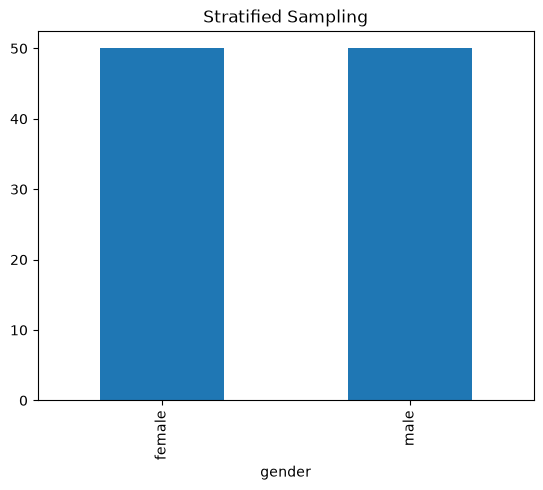

In [29]:
sample = df.groupby("gender").sample(50)

sample.groupby("gender").size().plot(kind="bar")

plt.title("Stratified Sampling")

plt.show()

#### Explanation: Each group contributes to the final sample.No group is ignored.

## 6.4) Cluster Sampling

### When the population is naturally divided into groups.

Examples: Schools,Villages,Companies

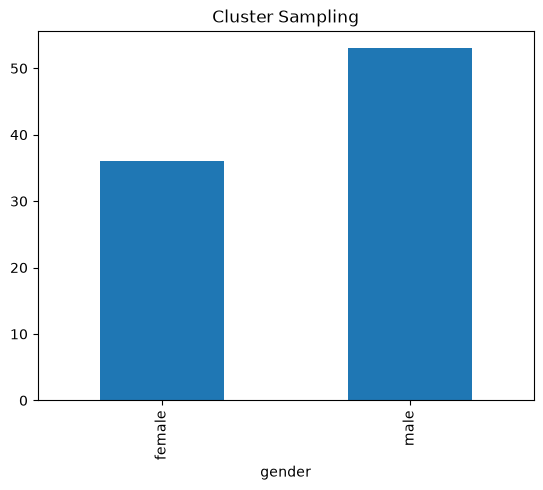

In [30]:
cluster = df[df["race/ethnicity"]=="group A"]

cluster.groupby("gender").size().plot(kind="bar")

plt.title("Cluster Sampling")

plt.show()

#### Explanation: Instead of selecting individuals,we select an entire group (cluster).

## 6.5) Convenience Sampling

### When quick data collection is needed.

Examples:
First 100 customers.
Nearby students.

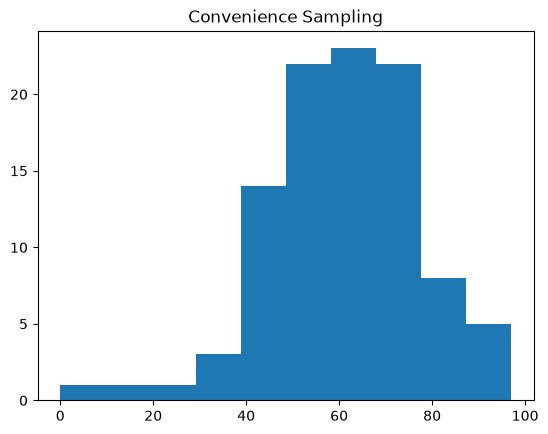

In [33]:
sample = df.head(100)

plt.hist(sample["math score"])

plt.title("Convenience Sampling")

plt.show()

#### Explanation: This sample is easy to collect,but it may not represent the whole population well.

## 6.6) Snowball Sampling

### Snowball sampling is not naturally represented in this dataset, so it is usually demonstrated with a simulated or network-style example rather than a real plot.

## 7) Central Limit Theorem

### When estimating population parameters or performing hypothesis tests.

Examples:
Confidence Interval
Hypothesis Testing

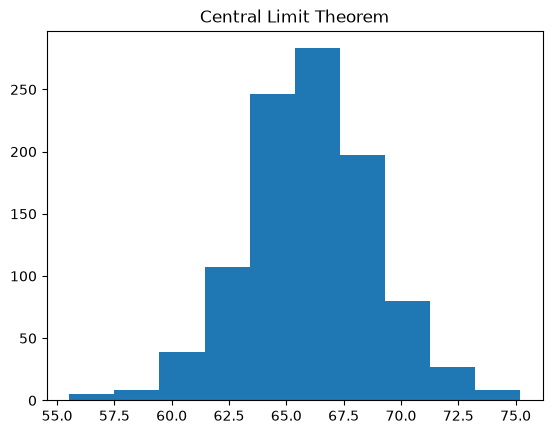

In [34]:
means = []

for i in range(1000):

    means.append(
        df["math score"].sample(30).mean()
    )

plt.hist(means)

plt.title("Central Limit Theorem")

plt.show()

#### Explanation: Even if the original data is not normally distributed,the distribution of sample means becomes approximately normal as the sample size increases.

## 8) Confidence Interval

### When estimating an unknown population mean.

Examples:
Average salary,
Average marks,
Average customer spending

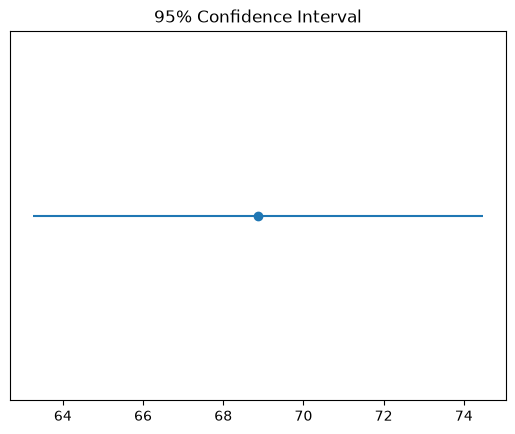

In [35]:
import numpy as np

sample = df["math score"].sample(30)

mean = sample.mean()

se = sample.std()/np.sqrt(30)

lower = mean-1.96*se
upper = mean+1.96*se

plt.errorbar(
    mean,
    1,
    xerr=[[mean-lower],[upper-mean]],
    fmt="o"
)

plt.yticks([])

plt.title("95% Confidence Interval")

plt.show()

#### Explanation: The point shows the sample mean.The horizontal error bar shows the range where the true population mean is likely to lie with 95% confidence.

## 9) Hypothesis Testing

### When testing whether a claim is supported by data.

Examples:
Average score = 60?,
New medicine is effective?,
New machine increases production?

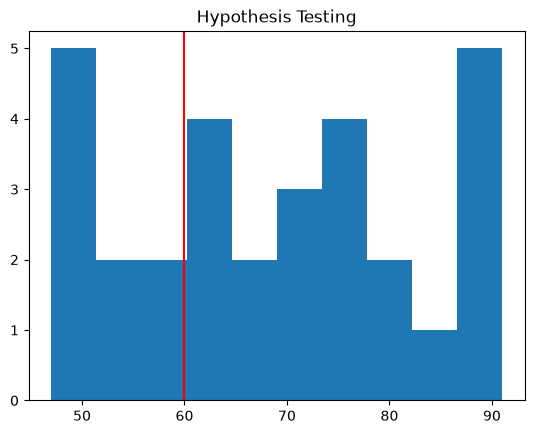

In [36]:
from scipy.stats import ttest_1samp

sample = df["math score"].sample(30)

t,p = ttest_1samp(sample,60)

plt.hist(sample)

plt.axvline(60,color="red")

plt.title("Hypothesis Testing")

plt.show()

#### Explanation: The histogram shows the sample scores.The red line represents the claimed population mean (60).The t-test checks whether the sample provides enough evidence to conclude that the true mean differs from 60.: 

## 10) p-value & Significance Level

### After performing a hypothesis test.

Examples:
Decide whether to reject the null hypothesis.

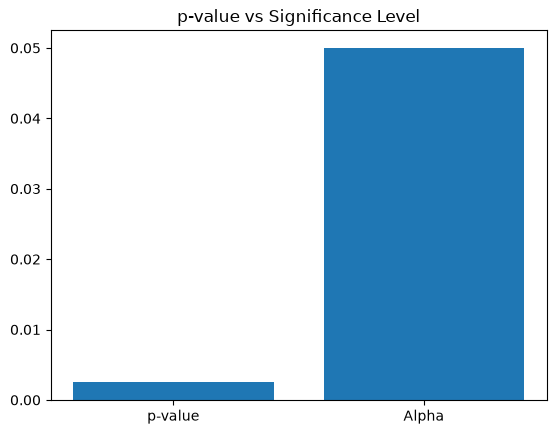

In [37]:
alpha = 0.05

labels = ["p-value", "Alpha"]
values = [p, alpha]

plt.bar(labels, values)

plt.title("p-value vs Significance Level")

plt.show()

#### Explanation: Compare the p-value with the significance level (α).If p-value < α, reject the null hypothesis.If p-value ≥ α, fail to reject the null hypothesis.This bar chart provides a visual comparison of the calculated p-value and the decision threshold, making it easier to explain why a statistical decision was made.